In [2]:
import xarray as xr
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')

from alldata import AllData
from ensemble import FullEnsemble,FullEnsemble2

In [3]:
ds1 = xr.open_dataset('../data/ensemble_1871.nc')
models = ds1.esm.values
ds1.close()

In [4]:
ad = AllData()
ad.year0 = 1951
ad.usefanom = True
ad.gather(update=False)

#Omit invalid ism
ad.ds = ad.ds.drop_sel(ism='PISM_DMI')

fe_f = FullEnsemble2(ad)
fe_f.nonlin = 'cutoff'
fe_f.lump = True
fe_f.gather(force_update=False)

fe_c = FullEnsemble(ad)
fe_c.cal = 'S'
fe_c.nonlin = 'cutoff'
fe_c.lump = True
fe_c.gather(force_update=False)



Gathered all data
Reading old saved ensemble  ../data/ensemble_fixed_fanom_cutoff_1951_lump.nc
Reading old saved ensemble  ../data/ensemble_calS_fanom_cutoff_1951_lump.nc


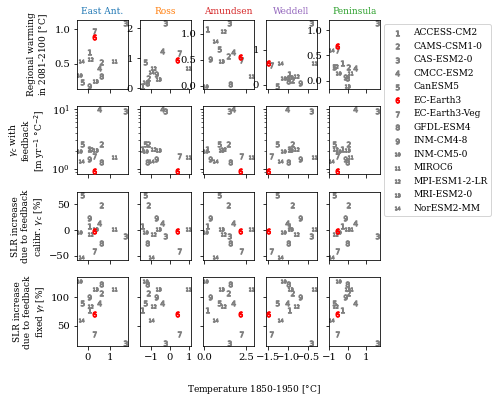

In [8]:
ssp = '245'

basinname = ['East Ant.','Ross','Amundsen','Weddell','Peninsula']

plt.style.use('../src/style_paper')
mpl.rc('figure.subplot',wspace=.25,hspace=.25,left=.15,right=.75)

fig,ax = plt.subplots(4,5,figsize=(7,6),sharex='col')

ds1 = xr.open_dataset(f'../data/eveline/thetao_sector_timeseries_historical+ssp{ssp}_1850_2100.nc')

for b,basin in enumerate(['eais','ross','amun','wedd','apen']):
    for m,model in enumerate(models):
        Thist = np.mean(ds1.sel(model=model)[basin].values[:100])
        Tfut = np.mean(ds1.sel(model=model)[basin].values[-21:-1])
        gamma_c = np.nanmean(fe_c.gamma.sel(option='wf',esm=model))
        slr_c_wf = np.nanmean(fe_c.slr.sel(option='wf',ssp=ssp,time=2100,esm=model))
        slr_c_nf = np.nanmean(fe_c.slr.sel(option='nf',ssp=ssp,time=2100,esm=model))
        slr_f_wf = np.nanmean(fe_f.slr.sel(opt2='wf',ssp=ssp,time=2100,esm=model))
        slr_f_nf = np.nanmean(fe_f.slr.sel(opt2='nf',ssp=ssp,time=2100,esm=model))        
        if model=='EC-Earth3':
            ax[1,b].scatter(Thist,gamma_c,30,color='r',marker=f'${m+1}$',label=model,zorder=10)
            ax[0,b].scatter(Thist,Tfut-Thist,30,color='r',marker=f'${m+1}$',label=model,zorder=10)
            ax[2,b].scatter(Thist,100*(slr_c_wf/slr_c_nf-1),30,color='r',marker=f'${m+1}$',label=model,zorder=10)
            ax[3,b].scatter(Thist,100*(slr_f_wf/slr_f_nf-1),30,color='r',marker=f'${m+1}$',label=model,zorder=10)
        else:
            ax[1,b].scatter(Thist,gamma_c,30,color='.5',marker=f'${m+1}$',label=model)
            ax[0,b].scatter(Thist,Tfut-Thist,30,color='.5',marker=f'${m+1}$',label=model)
            ax[2,b].scatter(Thist,100*(slr_c_wf/slr_c_nf-1),30,color='.5',marker=f'${m+1}$',label=model)
            ax[3,b].scatter(Thist,100*(slr_f_wf/slr_f_nf-1),30,color='.5',marker=f'${m+1}$',label=model)

    ax[1,b].set_yscale('log')
    if b>0:
        ax[1,b].set_yticklabels([])
        ax[2,b].set_yticklabels([])
        ax[3,b].set_yticklabels([])

    ax[0,b].set_title(ad.basin[b],c=ad.bcol[ad.basin[b]])
    
ax[1,0].set_ylabel('$\gamma_c$ with\nfeedback\n[m yr$^{-1}$ $\degree$C$^{-2}$]')
ax[0,0].set_ylabel('Regional warming\nin 2081-2100 [$\degree$C]')
ax[2,0].set_ylabel('SLR increase\ndue to feedback\ncalibr. $\gamma_c$ [%]')
ax[3,0].set_ylabel('SLR increase\ndue to feedback\nfixed $\gamma_f$ [%]')

ax[0,-1].legend(loc='upper right', bbox_to_anchor=(3.3,1))

fig.supxlabel('Temperature 1850-1950 [$\degree$C]')

plt.savefig('../draftfigs/esm_intercomp.png')

plt.show()